### Name: Se Rang Seo (Simon)

### Professor: Dr. Romanowsky

### Assignment 11: Convolutional Neural Network

# About:
I used a dataset to find fractured bones through imaging. The images are pictures of x-rays done on different parts of human body.

I used https://www.kaggle.com/code/prasadchaskar/bone-fracture-detection-97-accuracy-cnn to help me walk through using this dataset because of how difficult it was to even get started (loading files, working with directories, syntax, etc...).
I played around with different parameters like the networks and layers.

In [4]:
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers, models
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Simple GPU setup - use GPU if available, otherwise CPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✅ Using GPU: {gpus[0]}")
else:
    print("ℹ️ Using CPU (no GPU detected)")

ModuleNotFoundError: No module named 'tensorflow.keras'

In [ ]:
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU devices:", tf.config.list_physical_devices('GPU'))
print("All devices:", tf.config.list_physical_devices())

TensorFlow version: 2.21.0
Built with CUDA: False
GPU devices: []
All devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
# Define the paths to the datasets
base_dir = Path('Bone_fracture_binary_classification')
train_dir = base_dir / 'train'
test_dir = base_dir / 'test'
val_dir = base_dir / 'val'

In [ ]:
BATCH_SIZE = 32
IMG_HEIGHT = 180
IMG_WIDTH = 180

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                              image_size=(IMG_HEIGHT, IMG_WIDTH),
                                                              batch_size=BATCH_SIZE)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                              image_size=(IMG_HEIGHT, IMG_WIDTH),
                                                              batch_size=BATCH_SIZE)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(val_dir,
                                                              image_size=(IMG_HEIGHT, IMG_WIDTH),
                                                              batch_size=BATCH_SIZE)

Found 9246 files belonging to 2 classes.
Found 506 files belonging to 2 classes.
Found 829 files belonging to 2 classes.


In [ ]:
class_names = train_ds.class_names

def show_images(dataset, title):
    plt.figure(figsize=(6, 6))
    for images, labels in dataset.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i+1)
            plt.imshow(images[i].numpy().astype('uint8'))
            plt.title(class_names[labels[i]])
            plt.axis('off')
    plt.suptitle(title)
    plt.show()

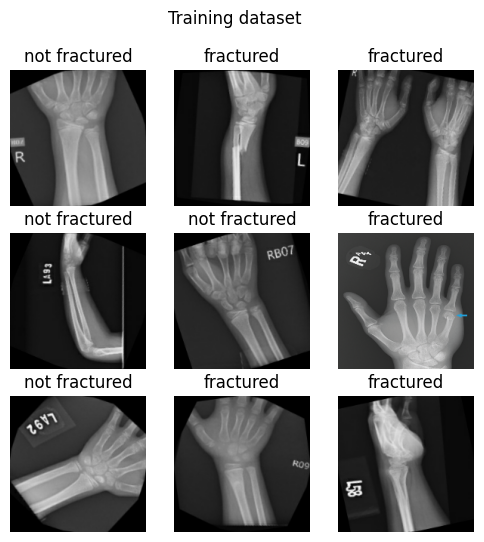

In [ ]:
show_images(train_ds, 'Training dataset')

In [ ]:
def count_classes(dataset, class_name):
    return len(list(Path.glob(dataset, f"{class_name}/*")))

def create_class_counts_df(dataset, class_names):
    counts = {'class':[], 'count': []}
    for class_name in class_names:
        counts['class'].append(class_name)
        counts['count'].append(count_classes(dataset, class_name))
    return pd.DataFrame(counts)

def plot_class_distribution(df, title, palette="viridis"):
    sns.barplot(x='class', y='count', data=df, palette=palette)
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

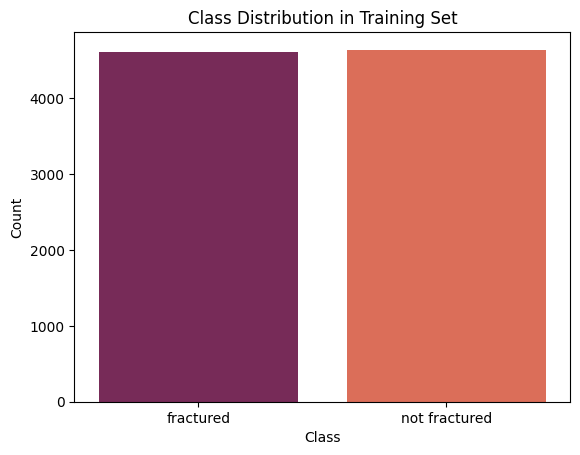

In [ ]:
train_df = create_class_counts_df(train_dir, class_names)
plot_class_distribution(train_df, 'Class Distribution in Training Set', palette='rocket')

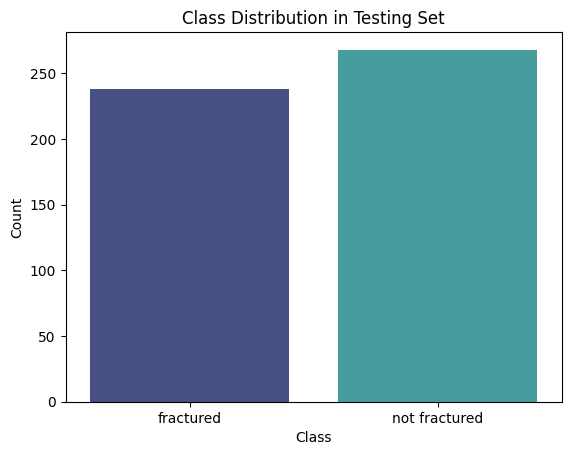

In [ ]:
test_df = create_class_counts_df(test_dir, class_names)
plot_class_distribution(test_df, 'Class Distribution in Testing Set', palette='mako')

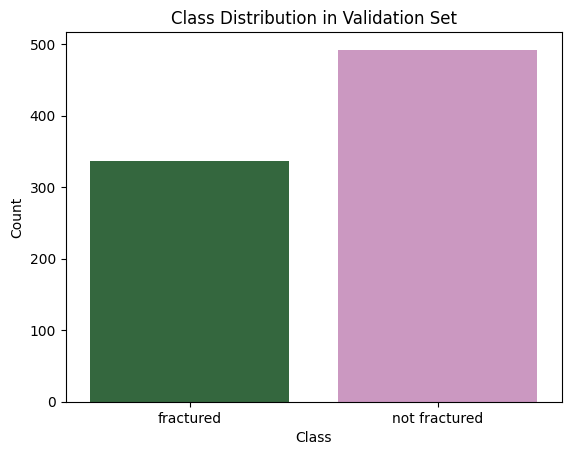

In [ ]:
val_df = create_class_counts_df(val_dir, class_names)
plot_class_distribution(val_df, 'Class Distribution in Validation Set', palette='cubehelix')

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
training_set = train_datagen.flow_from_directory(train_dir,
                                                target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                batch_size=32,
                                                class_mode='binary')

Found 9246 images belonging to 2 classes.


In [ ]:
test_set = train_datagen.flow_from_directory(test_dir,
                                                target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                batch_size=32,
                                                class_mode='binary')

Found 506 images belonging to 2 classes.


In [ ]:
val_set = train_datagen.flow_from_directory(val_dir,
                                                target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                batch_size=32,
                                                class_mode='binary')

Found 829 images belonging to 2 classes.


# Begin training: optimal version from Kaggle.

In [ ]:
model = models.Sequential([
    layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
from PIL import ImageFile

# This allows loading truncated images (may affect image quality)
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Then run your original code
history = model.fit(
    training_set,
    validation_data=test_set,
    epochs=5
)

Epoch 1/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 220s 756ms/step - accuracy: 0.7160 - loss: 0.5315 - val_accuracy: 0.8043 - val_loss: 0.5510
Epoch 2/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 106s 366ms/step - accuracy: 0.8867 - loss: 0.2812 - val_accuracy: 0.8340 - val_loss: 0.4067
Epoch 3/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 97s 333ms/step - accuracy: 0.9364 - loss: 0.1726 - val_accuracy: 0.8794 - val_loss: 0.3489
Epoch 4/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 115s 397ms/step - accuracy: 0.9568 - loss: 0.1262 - val_accuracy: 0.9249 - val_loss: 0.2196
Epoch 5/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 97s 334ms/step - accuracy: 0.9672 - loss: 0.0951 - val_accuracy: 0.9407 - val_loss: 0.1777


In [ ]:
test_loss, test_acc = model.evaluate(test_set)
print(f"Test Accuracy: {test_acc:.2f}")
print(f"Test Loss: {test_loss:.2f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 429ms/step - accuracy: 0.9348 - loss: 0.1859
Test Accuracy: 0.93
Test Loss: 0.19


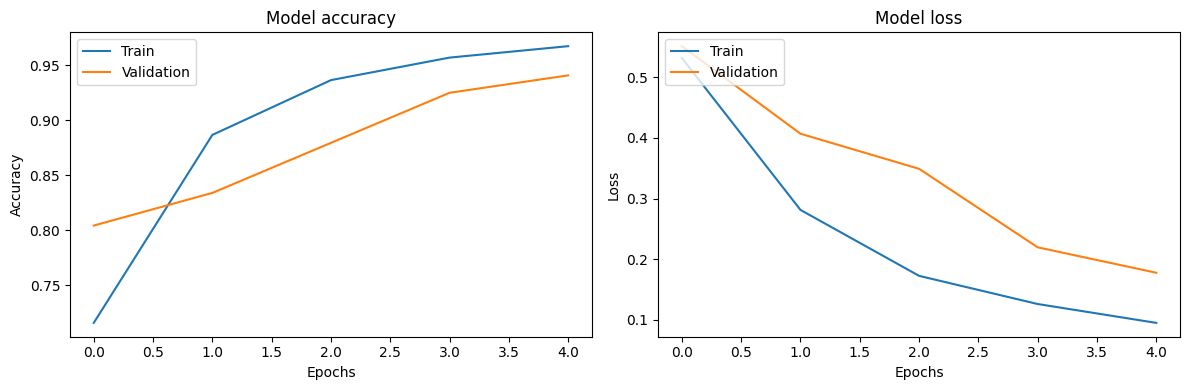

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Defining a general function to run models

I will run a bunch of variations of this CNN.

In [ ]:
def model(model,op='adam',loss='binary_crossentropy', metrics='accuracy', epoch=10):
    model.compile(optimizer=op,
              loss=loss,
              metrics= [metrics])

    # This allows loading truncated images (may affect image quality)
    ImageFile.LOAD_TRUNCATED_IMAGES = True

    # Then run your original code
    history = model.fit(
        training_set,
        validation_data=test_set,
        epochs=epoch
    )

    test_loss, test_acc = model.evaluate(test_set)
    print(f"Test Accuracy: {test_acc:.2f}")
    print(f"Test Loss: {test_loss:.2f}")
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title("Model accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Model loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()

# Global Average Pooling
Exploring different parameters and reducing epochs since 10 is too long.

In [ ]:
model_global_average_pooling = models.Sequential([
    layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),  # Instead of Flatten
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 95s 324ms/step - accuracy: 0.5867 - loss: 0.6698 - val_accuracy: 0.5553 - val_loss: 0.6800
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 93s 321ms/step - accuracy: 0.6522 - loss: 0.6195 - val_accuracy: 0.5929 - val_loss: 0.6585
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 93s 321ms/step - accuracy: 0.6997 - loss: 0.5761 - val_accuracy: 0.6739 - val_loss: 0.6335
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 93s 321ms/step - accuracy: 0.7356 - loss: 0.5350 - val_accuracy: 0.6917 - val_loss: 0.5933
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 92s 319ms/step - accuracy: 0.7787 - loss: 0.4780 - val_accuracy: 0.7431 - val_loss: 0.5298
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 100s 345ms/step - accuracy: 0.8231 - loss: 0.3983 - val_accuracy: 0.7747 - val_loss: 0.4235
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 101s 349ms/step - accuracy: 0.8488 - loss: 0.3453 - val_accuracy: 0.8083 - val_loss: 0.4822
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 93s 323ms/step - accuracy: 0.8515 - loss:

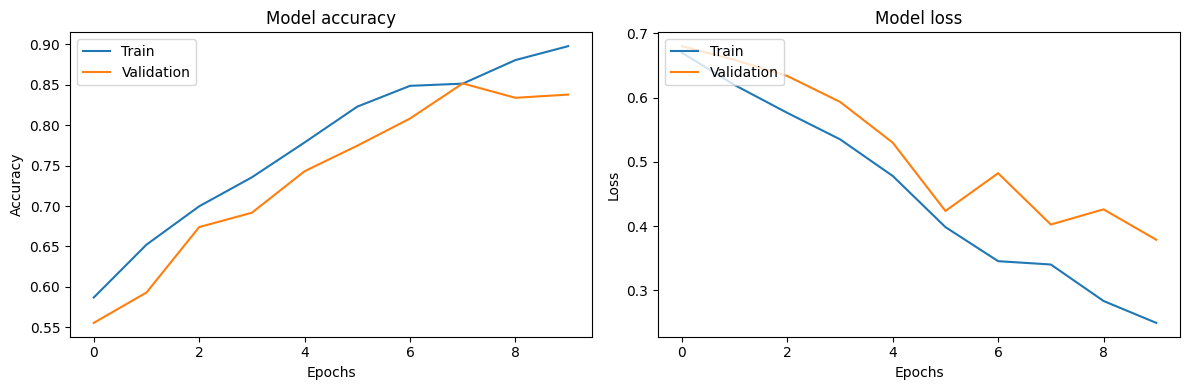

In [ ]:
model(model_global_average_pooling)

Next time I would run with less epoch to 6 epochs.

# Leaky RELU activation and Stochastic Gradient Descent

In [ ]:
model_leaky_relu = models.Sequential([
    layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='leaky_relu'),  # Leaky ReLU
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='leaky_relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='leaky_relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 100s 342ms/step - accuracy: 0.5845 - loss: 0.6649 - val_accuracy: 0.5593 - val_loss: 0.6745
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 97s 337ms/step - accuracy: 0.6622 - loss: 0.6088 - val_accuracy: 0.6621 - val_loss: 0.6310
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 97s 337ms/step - accuracy: 0.7254 - loss: 0.5455 - val_accuracy: 0.6897 - val_loss: 0.5882
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 97s 336ms/step - accuracy: 0.7674 - loss: 0.4885 - val_accuracy: 0.7411 - val_loss: 0.6304
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 97s 336ms/step - accuracy: 0.8046 - loss: 0.4323 - val_accuracy: 0.7727 - val_loss: 0.5294
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 99s 342ms/step - accuracy: 0.8242 - loss: 0.3900 - val_accuracy: 0.7826 - val_loss: 0.5088
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 98s 340ms/step - accuracy: 0.8581 - loss: 0.3363 - val_accuracy: 0.8103 - val_loss: 0.4470
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 98s 338ms/step - accuracy: 0.8744 - loss: 

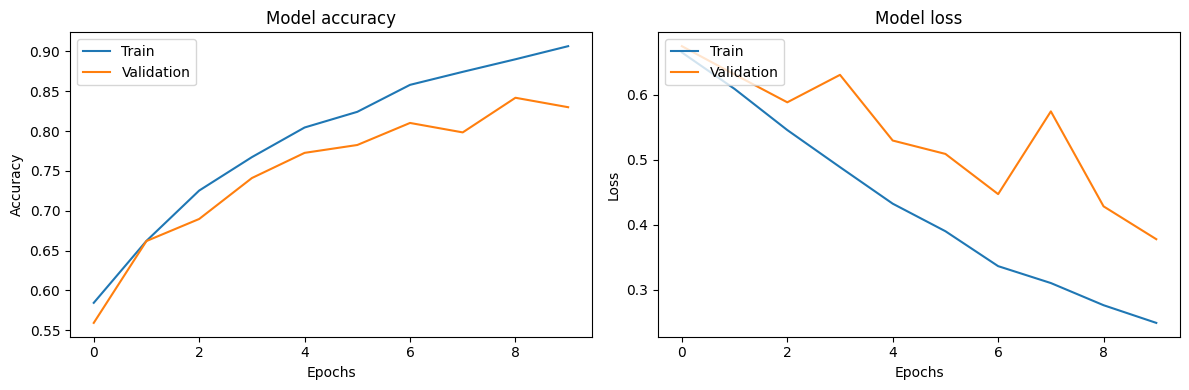

In [ ]:
model(model_leaky_relu,op='sgd')

This one is very wavey because of stochastic.

# More layers with RELU and SGD

In [ ]:
model_deep_relu = models.Sequential([
    layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model(model_deep_relu,op='sgd')

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 138s 475ms/step - accuracy: 0.5588 - loss: 0.6865 - val_accuracy: 0.5257 - val_loss: 0.6922
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 136s 469ms/step - accuracy: 0.6034 - loss: 0.6469 - val_accuracy: 0.5810 - val_loss: 0.7060
Epoch 3/10
198/289 ━━━━━━━━━━━━━━━━━━━━ 40s 442ms/step - accuracy: 0.6355 - loss: 0.6208

KeyboardInterrupt: 

Train and validations are crossing each other, but I would stop at 8 epochs.

# With dropout and relu activation

In [ ]:
model_dropout = models.Sequential([
    layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),  # Add dropout after pooling
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Higher dropout for dense layer
    layers.Dense(1, activation='sigmoid')
])

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 61s 209ms/step - accuracy: 0.6481 - loss: 0.6290 - val_accuracy: 0.6719 - val_loss: 0.6049
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 58s 202ms/step - accuracy: 0.7767 - loss: 0.4740 - val_accuracy: 0.7964 - val_loss: 0.4412
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 61s 212ms/step - accuracy: 0.8374 - loss: 0.3780 - val_accuracy: 0.8379 - val_loss: 0.3653
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 62s 214ms/step - accuracy: 0.8751 - loss: 0.3124 - val_accuracy: 0.8874 - val_loss: 0.2821
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 60s 209ms/step - accuracy: 0.8954 - loss: 0.2635 - val_accuracy: 0.8854 - val_loss: 0.3089
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 61s 209ms/step - accuracy: 0.9055 - loss: 0.2340 - val_accuracy: 0.9051 - val_loss: 0.2354
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 64s 221ms/step - accuracy: 0.9212 - loss: 0.1987 - val_accuracy: 0.8913 - val_loss: 0.2616
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 60s 209ms/step - accuracy: 0.9331 - loss: 0

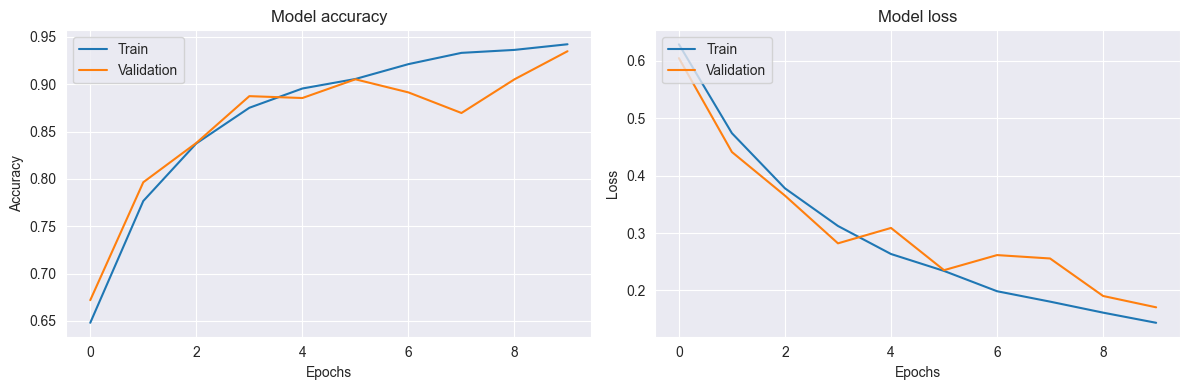

In [ ]:
model(model_dropout)

This is the 3rd best result I got.

# Larger Pooling and RMSprop optimizer

In [ ]:
model_larger_pool = models.Sequential([
    layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((3, 3)),  # Larger pool size
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((3, 3)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((3, 3)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 45s 154ms/step - accuracy: 0.6849 - loss: 0.5838 - val_accuracy: 0.7589 - val_loss: 0.4755
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 44s 153ms/step - accuracy: 0.8571 - loss: 0.3427 - val_accuracy: 0.8379 - val_loss: 0.3486
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 45s 157ms/step - accuracy: 0.9180 - loss: 0.2057 - val_accuracy: 0.8676 - val_loss: 0.2696
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 48s 165ms/step - accuracy: 0.9487 - loss: 0.1408 - val_accuracy: 0.9012 - val_loss: 0.2933
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 47s 163ms/step - accuracy: 0.9624 - loss: 0.1029 - val_accuracy: 0.9348 - val_loss: 0.1833
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 47s 162ms/step - accuracy: 0.9732 - loss: 0.0802 - val_accuracy: 0.9585 - val_loss: 0.1520
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 46s 159ms/step - accuracy: 0.9764 - loss: 0.0661 - val_accuracy: 0.9447 - val_loss: 0.2102
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 47s 161ms/step - accuracy: 0.9825 - loss: 0

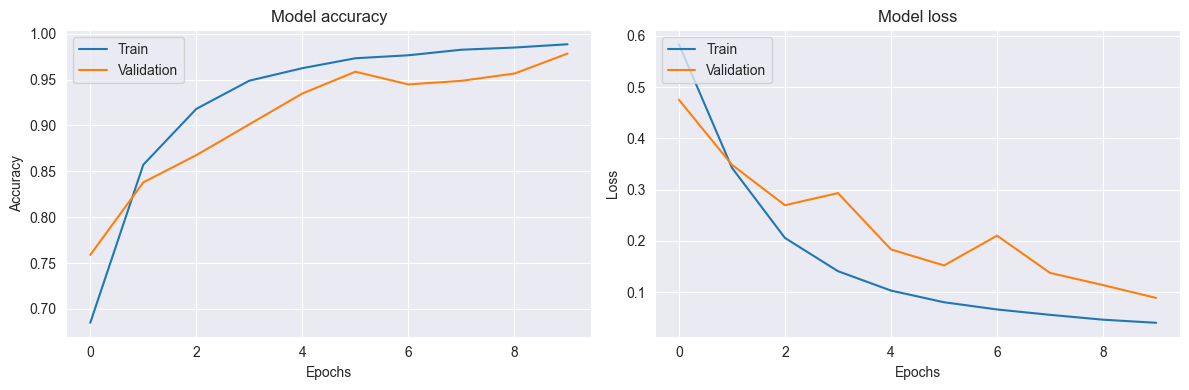

In [ ]:
model(model_larger_pool,op='rmsprop')

This result is the best I got. The one from Kaggle was only 96% and 0.14 Loss while this one is 98% and 0.06.

# Mixed kernal sizes with RELU and Adaptive Learning Rate

In [ ]:
model_kernel = models.Sequential([
    layers.InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),  # Different kernel size
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 65s 225ms/step - accuracy: 0.5596 - loss: 0.6795 - val_accuracy: 0.5375 - val_loss: 0.6885
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 68s 235ms/step - accuracy: 0.6029 - loss: 0.6504 - val_accuracy: 0.5731 - val_loss: 0.6734
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 68s 236ms/step - accuracy: 0.6582 - loss: 0.6148 - val_accuracy: 0.5830 - val_loss: 0.6860
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 65s 224ms/step - accuracy: 0.6945 - loss: 0.5759 - val_accuracy: 0.6383 - val_loss: 0.6195
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 67s 232ms/step - accuracy: 0.7278 - loss: 0.5429 - val_accuracy: 0.6818 - val_loss: 0.6482
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 70s 242ms/step - accuracy: 0.7494 - loss: 0.5092 - val_accuracy: 0.6225 - val_loss: 0.6448
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 69s 238ms/step - accuracy: 0.7772 - loss: 0.4745 - val_accuracy: 0.7233 - val_loss: 0.5715
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 69s 239ms/step - accuracy: 0.7923 - loss: 0

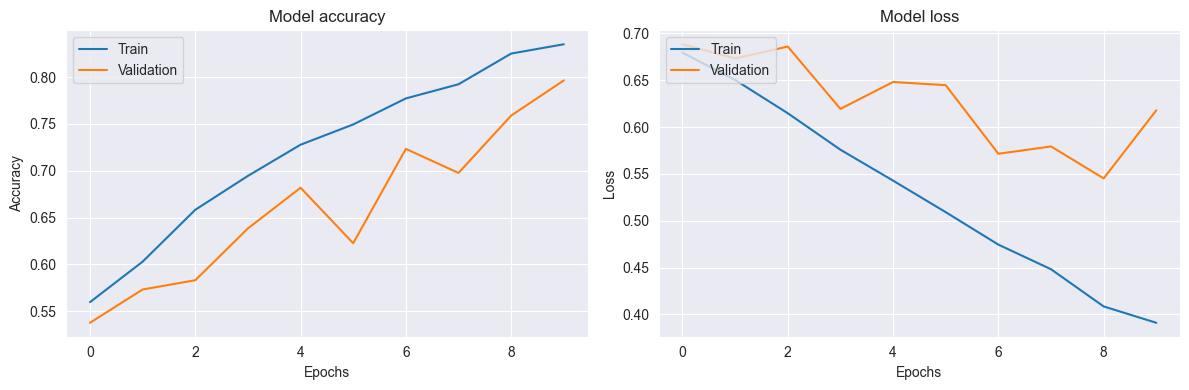

In [ ]:
model(model_kernel,op='adagrad')

Worst result.

This concludes my CNN assignment.

1st best result: Large pool and RMSProp optimizer. 98% accuracy and 0.06 loss

2nd best result: from Kaggle using adam optimizer. 96% accuracy and 0.14 loss

3rd best result: without dropouts using RELU and adam optimizer. 93% accuracy and 0.15 loss